**bold text**<p style="text-align: center; font-size: 28px; font-weight: bold;">CIND 123</p>
<p style="text-align: center; font-size: 24px; font-weight: bold;">Data Analytics: Basic Methods</p>
<p style="text-align: center; font-size: 24px; font-weight: bold;">Assignment 1 (15%)</p>

**[Carlos Elizondo]**  
**[CIND 123 DJ0 W2026, Student number: 500890062]**

<p style="text-align: center; font-size: 20px; font-weight: bold;">Instructions</p>

This assignment can be submitted using either Python or R, whichever you prefer.

- **If using R**, you must submit an RMD file with its knitted file (PDF or HTML). To learn more about knitting and R markdown, visit [R Markdown](http://rmarkdown.rstudio.com).
- **If using Python**, you must submit an IPYNB file and its exported PDF/HTML with clearly printed/shown answers.

Failing to submit both files ({RMD + knitted PDF/HTML} OR {IPYNB + PDF/HTML}) will be subject to a 30% mark deduction.

**NOTE:** IF YOU USE `R STUDIO`, YOU SHOULD NEVER HAVE `install.packages` IN YOUR CODE; OTHERWISE, THE `Knit` OPTION WILL RAISE AN ERROR. COMMENT OUT ALL PACKAGE INSTALLATIONS BUT KEEP `library()` CALLS.

**NOTE:** If you answer the questions in R, all your answers should be in R (ignore Python questions). If you answer the questions in Python, all your answers should be in Python (ignore R questions). You are not allowed to switch languages in this assignment.

<p style="font-size: 24px; font-weight: bold;">Question 1 (60 points)</p>

The Titanic Passenger Survival Data Set provides information on the fate of passengers on the fatal maiden voyage of the ocean liner “Titanic.” The dataset is available from the kaggle website ([Titanic Dataset](https://www.kaggle.com/c/titanic/data)) in several formats. Download the Titanic Data Set `titanic.csv` which is given on assignment's page. Then, read it using the appropriate commands in `R` or `Python`.


| Column Name | Description                         | Values                                  |
|-------------|-------------------------------------|-----------------------------------------|
| survival    | Survival                            | 0 = No, 1 = Yes                         |
| pclass      | Ticket class                        | 1 = 1st, 2 = 2nd, 3 = 3rd               |
| sex         | Sex                                 |                                         |
| age         | Age in years                        |                                         |
| sibsp       | # of siblings / spouses aboard the Titanic |                                         |
| parch       | # of parents / children aboard the Titanic |                                         |
| ticket      | Ticket number                       |                                         |
| fare        | Passenger fare                      |                                         |
| cabin       | Cabin number                        |                                         |
| embarked    | Port of Embarkation                 | C = Cherbourg, Q = Queenstown, S = Southampton |

In [1]:
#loading libraries incase we need them during assignment
import pandas as pd
import numpy as np
#loading the dataset
df=pd.read_csv("/content/sample_data/titanic.csv")
#Displaying first 5 rows to make sure it loaded correctly
df.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


<p style="font-size: 20px; font-weight: bold;">Q1a (5 points)</p>

Extract and show the columns `name`, `fare`, `sibsp`, and `parch` into a new data frame (or DataFrame in Python) named `titanicSubset`.

Show/print the `head` of the dataframe.

In [2]:
#making a subset from the dataframe with the following columns
titanicSubset=df[['name','fare','sibsp','parch']]
#showing the head of the data frame
titanicSubset.head()

,name,fare,sibsp,parch
0,"Allen, Miss. Elisabeth Walton",211.3375,0,0
1,"Allison, Master. Hudson Trevor",151.5500,1,2
2,"Allison, Miss. Helen Loraine",151.5500,1,2
3,"Allison, Mr. Hudson Joshua Creighton",151.5500,1,2
4,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",151.5500,1,2


# <p style="font-size: 20px; font-weight: bold;">Q1b (5 points)</p>

Numerical data: Calculate the total number of passengers who were children (age less than 25) and survived.

Print the value.

In [3]:
# Filtering the titanic dataframe for both conditions
children_survived = df[(df['age'] < 25) & (df['survived'] == 1)]

# Calculating the count using len()
total_children_survived = len(children_survived)

# Printing the value
print("The total number of children (under 25) who survived is",total_children_survived)

The total number of children (under 25) who survived is 177


<p style="font-size: 20px; font-weight: bold;">Q1c (5 points)</p>

Categorical data: Calculate the number of passengers by sex.

Print the value.

In [4]:
#Filtering for male passengers in the dataframe
male_passengers = df[df['sex'] == 'male']

#filtering for female passengers in the dataframe
Female_passengers = df[df['sex'] == 'female']

#printing the values
print("The number of male passengers is",len(male_passengers))
print("The number of female passengers is",len(Female_passengers))

The number of male passengers is 843
The number of female passengers is 466


<p style="font-size: 20px; font-weight: bold;">Q1d (5 points)</p>

Find the passengers in the data frame whose age information is missing, and fill them with the median age of passengers.

Show the head of the dataframe.

In [5]:
#to know how many missing value we can run information function on the dataframe
df.info()
#from here we know there are 1309 entries andage has 1046 non-null meaning we need 263 entries to be changed to the median
#to calculate the median age
median_age = df['age'].median()
print("The median age is",median_age)
#to fill missing values with the median age in the age column
df['age'].fillna(median_age, inplace=True)
#showing info again to verify we removed all missing values, it now shows 1309 entries
df.info()
#showing head of dataframe
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pclass     1309 non-null   int64  
 1   survived   1309 non-null   int64  
 2   name       1309 non-null   object 
 3   sex        1309 non-null   object 
 4   age        1046 non-null   float64
 5   sibsp      1309 non-null   int64  
 6   parch      1309 non-null   int64  
 7   ticket     1309 non-null   object 
 8   fare       1308 non-null   float64
 9   cabin      295 non-null    object 
 10  embarked   1307 non-null   object 
 11  boat       486 non-null    object 
 12  body       121 non-null    float64
 13  home.dest  745 non-null    object 
dtypes: float64(3), int64(4), object(7)
memory usage: 143.3+ KB
The median age is 28.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     ---

/tmp/ipykernel_2862/1521099295.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(median_age, inplace=True)


,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


<p style="font-size: 20px; font-weight: bold;">Q1e (10 points)</p>

Calculate the survival count of each passenger class (`pclass`) and calculate the survival rate of passengers in each class. Draw a conclusion on which passenger class has the highest survival rate.

**Hint**: You may use the `aggregate()` function or any alternative function you know of.

Print the value and type your response as a comment.

In [6]:
# Calculating the survival count per class
Survival_count=df.groupby('pclass')['survived'].sum()
# Calculating the survival rate per class
survival_rate=Survival_count/df['pclass'].value_counts()
print("The survival count per class is",Survival_count)
print("The survival rate per class is",survival_rate)

The survival count per class is pclass
1    200
2    119
3    181
Name: survived, dtype: int64
The survival rate per class is pclass
1    0.619195
2    0.429603
3    0.255289
dtype: float64


The survial count per class is:
1.   Class 1 = 200
2.   Class 2 = 119
3.   Class 3 = 181

The survial rate per class is:
*   Class 1 = 61.92%
*   Class 2 = 42.96%
*   Class 3 = 25.53%

Class 1 has the highest survival rate with 62% chance of survival



/tmp/ipykernel_2862/3604175452.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=survival_rate.index, y=survival_rate.values, palette="viridis")


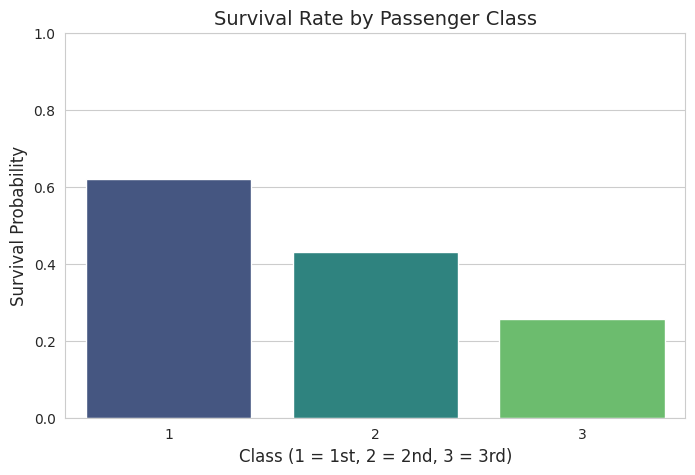

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Using the data you already calculated in Q1e
plt.figure(figsize=(8, 5))
sns.set_style("whitegrid")
ax = sns.barplot(x=survival_rate.index, y=survival_rate.values, palette="viridis")

# Adding labels to make it look professional
plt.title('Survival Rate by Passenger Class', fontsize=14)
plt.xlabel('Class (1 = 1st, 2 = 2nd, 3 = 3rd)', fontsize=12)
plt.ylabel('Survival Probability', fontsize=12)
plt.ylim(0, 1) # Probability is 0 to 1

# Export for GitHub
plt.savefig('survival_by_class.png', dpi=300, bbox_inches='tight')
plt.show()

# <p style="font-size: 20px; font-weight: bold;">Q1f (10 points)</p>

Use a boxplot to display the distribution of fare for each sex. Infer which gender tends to pay higher fares.

Have the plot and then your comment.

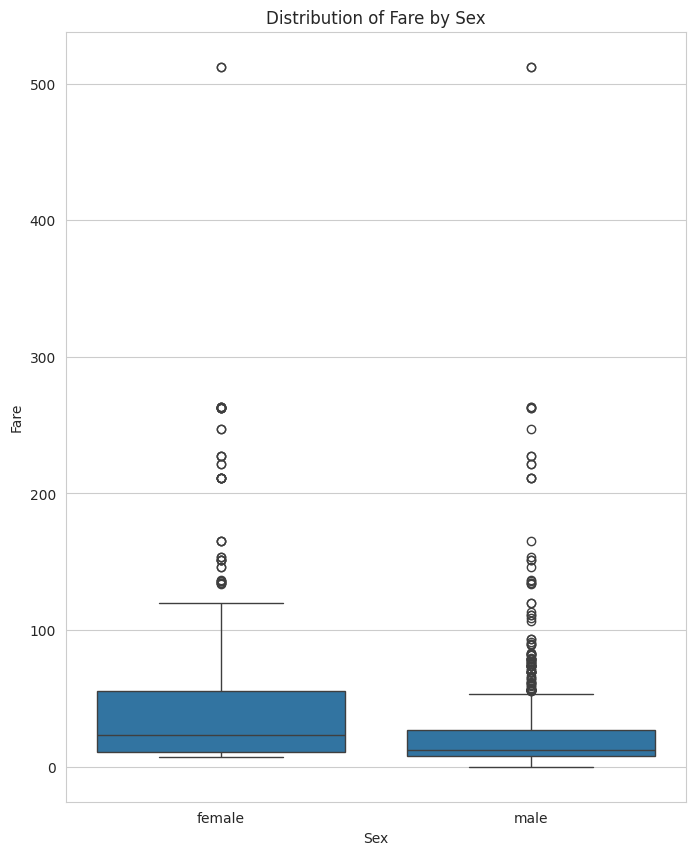

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Making a boxplot to display the distribution of fare for each sex
plt.figure(figsize=(8, 10))
sns.boxplot(x='sex', y='fare', data=df)
plt.title('Distribution of Fare by Sex')
plt.xlabel('Sex')
plt.ylabel('Fare')
plt.savefig('Distribution_of_Fare_by_Sex.png', dpi=300, bbox_inches='tight')
plt.show()

Based on the box plot females tend to pay higher fares. We can see that the median line is higher for females and the box itself is positioned higher than the male's.

<p style="font-size: 20px; font-weight: bold;">Q1g (10 points)</p>

Calculate the mean fare for each sex. Describe if the calculation aligns with the boxplot.

Print the value and comment on it.

In [9]:
mean_fare_by_sex = df.groupby('sex')['fare'].mean()
print("mean fare by sex:\n", mean_fare_by_sex)

mean fare by sex:
 sex
female    46.198097
male      26.154601
Name: fare, dtype: float64


As we can see the mean of females is 46.198 which is greater than the male mean of 26.155. The mean is also known as the average, signifying that the average female pays more than the average male

<p style="font-size: 20px; font-weight: bold;">Q1h (10 points)</p>

Use a `for` loop and `if` control statements to list the names of women, aged 50 or older, who embarked from Southampton (`S`) on the Titanic. Ensure these women have non-empty home destinations.

Print first 5 people only.

In [10]:
results = []
for index, row in df.iterrows():
# 1. Condition: Female
# 2. Condition: Aged 50 or older
# 3. Condition: Embarked from Southampton ('S')
# 4. Condition: Non-empty home destination (not NaN)
    if (row['sex'] == 'female') and (row['age'] >= 50) and (row['embarked'] == 'S') and (pd.notna(row['home.dest'])):results.append(row['name'])
# Printing first 5 people only
print("First 5 women (50+) from Southampton with a home destination:")
for name in results[:5]:
    print(name)

First 5 women (50+) from Southampton with a home destination:
Andrews, Miss. Kornelia Theodosia
Appleton, Mrs. Edward Dale (Charlotte Lamson)
Bonnell, Miss. Elizabeth
Brown, Mrs. John Murray (Caroline Lane Lamson)
Cavendish, Mrs. Tyrell William (Julia Florence Siegel)


Question 2 (20 points)

A hospital pharmacy prepares 100 medication doses daily. Based on historical data, each dose has a 3% probability of being incorrectly prepared, requiring disposal.

Q2a (10 points)

Calculate the probability that at least 5 doses are incorrectly prepared in a given day.

In [11]:
from scipy.stats import binom
n = 100  # Number of medication doses
p = 0.03 # Probability of incorrect preparation
#The probability that AT LEAST 5 doses are incorrect (P(X >= 5))
#Which is equal to 1 - P(X <= 4)
prob_at_least_5 = 1 - binom.cdf(4, n, p)
print(f"Q2a: The probability that at least 5 doses are incorrect is: {prob_at_least_5:.4f}")

Q2a: The probability that at least 5 doses are incorrect is: 0.1821


Q2b (10 points)

Estimate the number of incorrectly prepared doses in a day using an appropriate probability distribution.


In [12]:
#Estimating the number of incorrectly prepared doses will require the Expected Value
#Formula: E[X] = n * p
expected_value = n * p
print(f"Q2b: The estimated number of incorrectly prepared doses in a day is: {expected_value}")

Q2b: The estimated number of incorrectly prepared doses in a day is: 3.0


Question 3 (20 points)

A call center receives an average of 3 customer complaints per hour.

Q3a (10 points)

Calculate the probability that the call center receives exactly 5 complaints in an hour.

In [13]:
from scipy.stats import poisson
mu = 3 # Average complaints per hour
prob_exactly_5 = poisson.pmf(5, mu)
print("The probability of exactly 5 complaints is:", prob_exactly_5)

The probability of exactly 5 complaints is: 0.10081881344492458


Q3b (10 points)

Estimate the number of complaints received in an hour.


In [14]:
# In a Poisson distribution, the estimate (mean) is the rate itself
print("The estimated number of complaints received in an hour is:",mu)

The estimated number of complaints received in an hour is: 3


This is the end of Assignment 1.